In [27]:
import numpy as np
import pandas as pd
import h5py
from astropy.io import fits
import warnings
from tqdm import tqdm


In [71]:

def populate_sdss_fields(objs, progress_bar=False):
    print(f"Populating SDSS fields: {len(objs)}", flush=True)
    cat = pd.read_parquet(f"data/S82/Catalog.parquet").set_index('idx')
    hdul = fits.open('data/dr16q_prop_May01_2024.fits')
    fits_data = hdul[1].data  # Assuming the data is in the first extension    
    fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    
    for d in tqdm(objs, desc="Populating SDSS fields", disable=(not progress_bar)):
        obj = cat.loc[cat['objectId'] == d['object_id']].iloc[0]
        i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
        if len(i) == 0:
            print(f"Warning: {d['sdss_name']} not found in SDSS data")
            return d

        i = i[0]
        if np.any(fits_data_2['PSFFLUX'][i,:] <= 0):
            #print(f"Warning: {d['sdss_name']} has non-positive PSFFLUX values")
            continue
        
        d['z'] = obj['Z_SYS']
        d['sdss_name'] = fits_data['SDSS_NAME'][i]  # Extract SDSS_NAME
        d['ebv'] = fits_data['EBV'][i]

    return objs

sdss_objs = populate_sdss_fields(objs, progress_bar=True)
print(len(objs))
print(len(sdss_objs))

Populating SDSS fields: 38825


Populating SDSS fields: 100%|██████████| 38825/38825 [02:11<00:00, 294.69it/s]

38825
38825


In [55]:
def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in hdf.keys():
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list


objs = read_quasars_from_hdf5("data/may8_lc_all.h5")
print(len(objs))

38825


In [82]:
sdss_objs_filtered = [obj for obj in sdss_objs if obj.get('ebv', np.inf) < 0.05]
print(f"Filtered objects: {len(sdss_objs_filtered)}")

Filtered objects: 27769


In [100]:
import numpy as np
from scipy.stats import median_abs_deviation as mad
from multiprocessing import cpu_count, Pool
from tqdm import tqdm
import pandas as pd

def reject_outliers_moving_window(times, mags, mag_errs, window_size=6, sigma_thresh=2.5):
    mags = np.array(mags)
    times = np.array(times)
    mag_errs = np.array(mag_errs)

    if len(mags) < 2 * window_size + 1:
        return mags, mag_errs

    mask = np.ones(len(mags), dtype=bool)

    for i in range(len(mags)):
        if i < window_size or i >= len(mags) - window_size:
            continue
        window = mags[i - window_size:i + window_size + 1]
        window_mad = mad(window, nan_policy='omit')
        window_mean = np.nanmean(window)

        if window_mad == 0:
            continue

        if np.abs(mags[i] - window_mean) > sigma_thresh * window_mad:
            mask[i] = False

    return mags[mask], mag_errs[mask]

def chi_squared_variability(mags, mag_errs):
    """Compute reduced chi-squared assuming a constant (non-variable) source."""
    mags = np.array(mags)
    mag_errs = np.array(mag_errs)

    if len(mags) <= 1:
        return np.nan

    weights = 1.0 / mag_errs**2
    weighted_mean = np.sum(weights * mags) / np.sum(weights)

    chi_sq = np.sum(((mags - weighted_mean) / mag_errs) ** 2)
    chi_sq_red = chi_sq / (len(mags) - 1)
    return chi_sq_red

def rank_agn_by_chi_squared(object_id, lc_data, window_size=6, sigma_thresh=2.5, band='g'):
    """
    Rank AGN light curves using reduced chi-squared after outlier rejection.
    """
    times, mags, mag_errs = lc_data['times'][band], lc_data['mags'][band], lc_data['magerrs'][band]
    mags_clean, mag_errs_clean = reject_outliers_moving_window(
        times, mags, mag_errs, window_size, sigma_thresh)

    if len(mags_clean) < 2:
        return object_id, np.nan

    chi_sq = chi_squared_variability(mags_clean, mag_errs_clean)
    return object_id, chi_sq

def rank_multiband_light_curves_chi_squared(light_curves):
    results = []
    for lc_data in tqdm(light_curves, desc="Ranking light curves (chi-squared)"):
        r = rank_agn_by_chi_squared(lc_data['object_id'], lc_data)
        try:
            object_id, chi_sq = r
            results.append(dict(object_id=object_id, chi_sq=chi_sq, ebv=lc_data['ebv'], z=lc_data['z']))
        except Exception as e:
            print(f"Error processing light curve for object_id {lc_data['object_id']}: {r}")
            print(e)
            continue

    ranking_df = pd.DataFrame(results)
    ranking_df.sort_values('chi_sq', ascending=False, inplace=True)
    return ranking_df.reset_index(drop=True)

df = rank_multiband_light_curves_chi_squared(sdss_objs_filtered)


Ranking light curves (chi-squared): 100%|██████████| 27769/27769 [01:58<00:00, 235.07it/s]


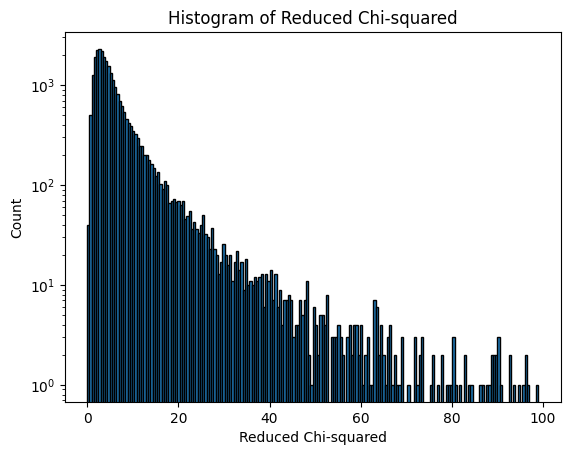

In [131]:
plt.hist(df[df['chi_sq']<100]['chi_sq'], bins=200, edgecolor='black')
plt.xlabel('Reduced Chi-squared')
plt.ylabel('Count')
plt.title('Histogram of Reduced Chi-squared')
plt.yscale('log')
#plt.xscale('log')

plt.show()

In [101]:
df.dropna(inplace=True)
df

,object_id,chi_sq,ebv,z
0,1393776,1989.249501,0.018843,1.939462
1,1412082,1338.640163,0.028161,2.470196
2,1447754,643.876301,0.026590,1.453559
3,1402700,561.897539,0.025979,2.163174
4,1405335,461.021345,0.020898,1.388572
...,...,...,...,...
27757,1464811,0.181181,0.035607,4.957475
27758,1419214,0.103226,0.026514,4.697184
27759,1396269,0.058051,0.024892,0.411570
27760,1413639,0.036075,0.028448,0.518915


In [140]:
good_sources = df[df['chi_sq'] > 5]
good_sources = good_sources[good_sources['ebv'] < 0.05]
good_sources = good_sources.sample(frac=1, random_state=42).reset_index(drop=True)
good_sources.to_csv('data/may22_good_sources_chisq5and10.csv', index=False)
len(good_sources)

11897

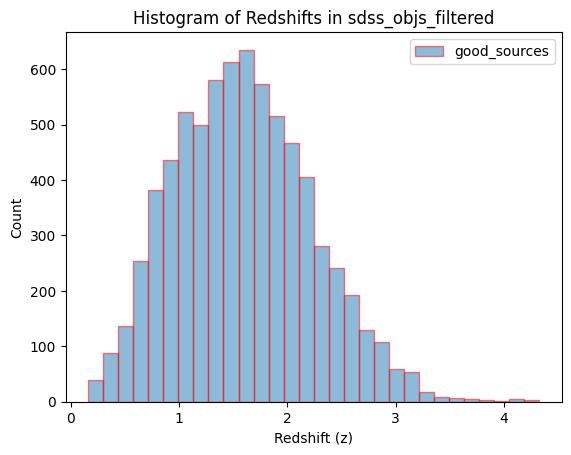

In [128]:
import matplotlib.pyplot as plt

plt.hist(good_sources['z'], bins=30, edgecolor='red', alpha=0.5, label='good_sources')
plt.legend()
plt.xlabel('Redshift (z)')
plt.ylabel('Count')
plt.title('Histogram of Redshifts in sdss_objs_filtered')
plt.show()

In [106]:
df.to_csv("data/may22_agn_all_ranked_chi2.csv", index=False)

In [107]:
df_sel = df[:4000]
df_sel = df_sel.sample(frac=1, random_state=42).reset_index(drop=True)
df_sel.to_csv("data/may22_agn_all_ranked_chi2_4000.csv", index=False)

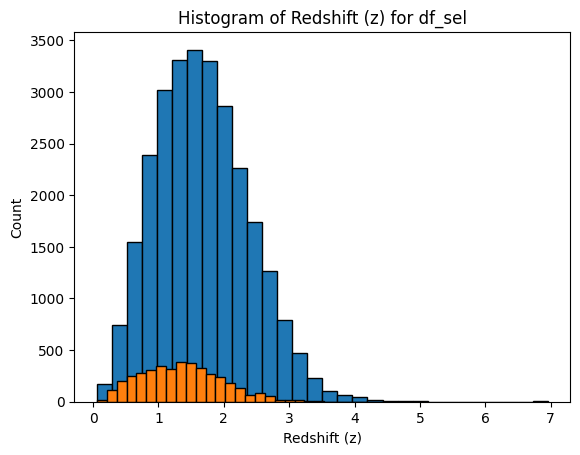

In [108]:
import matplotlib.pyplot as plt

plt.hist(df['z'], bins=30, edgecolor='black')
plt.hist(df_sel['z'], bins=30, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('Count')
plt.title('Histogram of Redshift (z) for df_sel')
plt.show()

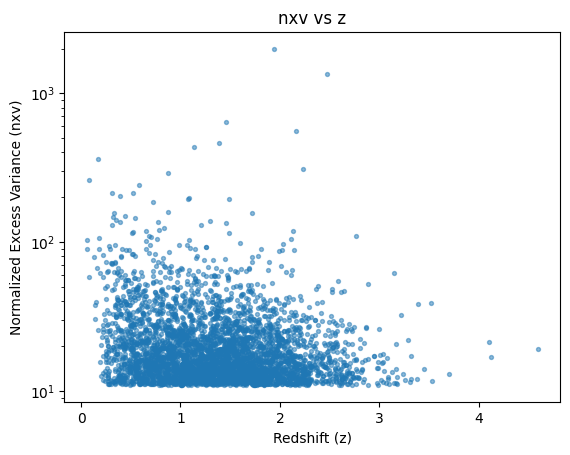

In [111]:
plt.scatter(df_sel['z'], df_sel['chi_sq'], alpha=0.5, s=8)
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Excess Variance (nxv)')
plt.title('nxv vs z')
plt.yscale('log')
plt.show()

In [87]:
df = df[df['ebv'] < 0.05]
len(df)

27769

In [64]:
d = df[df['total_observations'] > 800]
d

,object_id,robust_avg_nxv,total_observations,combined_score
28,1459958,0.001931,986,0.005780
66,1463119,0.000966,963,0.002882
78,1427359,0.000903,811,0.002627
88,1424290,0.000785,973,0.002344
108,1465974,0.000661,1060,0.001999
...,...,...,...,...
35723,1451585,0.000003,1612,0.000010
36016,1401309,0.000003,805,0.000009
36391,1385141,0.000002,1089,0.000006
36473,1464956,0.000002,1317,0.000005


In [65]:
d.to_csv('data/s82_lc_ranking.csv', index=False)